In [39]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def Plot(q2,title,clim=None):
    # Determine coordinate names
    lonname = 'lon' if 'lon' in q2.dims else 'longitude'
    latname = 'lat' if 'lat' in q2.dims else 'latitude'
    
    # Create plot
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plot the data
    if clim is None:
        q2.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis')
    else:
        q2.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis',vmin=clim[0],vmax=clim[1])
    
    # Add geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    
    # Add Texas city names
    texasCities = {
        "Houston": (29.7604, -95.3698),
        "Dallas": (32.7767, -96.7970),
        "Austin": (30.2672, -97.7431),
        "San Antonio": (29.4241, -98.4936),
        "Fort Worth": (32.7555, -97.3308),
        "El Paso": (31.7619, -106.4850),
        "Lubbock": (33.5779, -101.8552),
        "Amarillo": (35.2219, -101.8313),
        "Corpus Christi": (27.8006, -97.3964),
        "Laredo": (27.5306, -99.4803)
    }
    
    for city, (lat, lon) in texasCities.items():
        ax.plot(lon, lat, marker='o', color='red', markersize=2, transform=ccrs.PlateCarree())
        ax.text(lon + 0.3, lat + 0.3, city, fontsize=8, transform=ccrs.PlateCarree(), color='black')
    
    # Gridlines and title
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    plt.title(title)

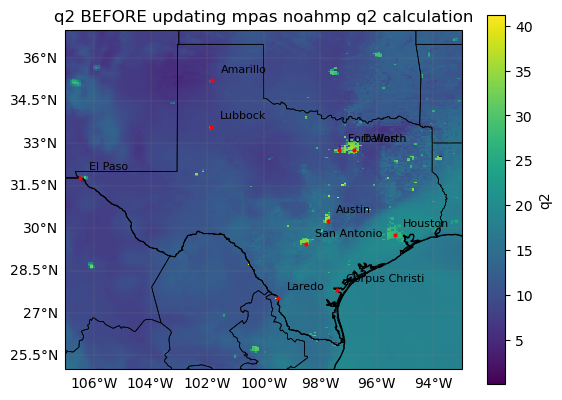

In [50]:
#BEFORE FIX
import xarray as xr
filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/backup_20-1km_56nz/diag_cartesian/diag.2022-06-30_00.30.00.latlon.nc"
data = xr.open_dataset(filePath)
q2 = data['q2']

q2 = q2.sel(
    {latname: slice(25, 37), lonname: slice(-107, -93)}
)* 1000

Plot(q2,title="q2 BEFORE updating mpas noahmp q2 calculation")

In [51]:
#getting clim
plotHandle = q2.plot();
clim = plotHandle.get_clim(); print(clim)
plt.close()

(0.07544805109500885, 41.229557037353516)


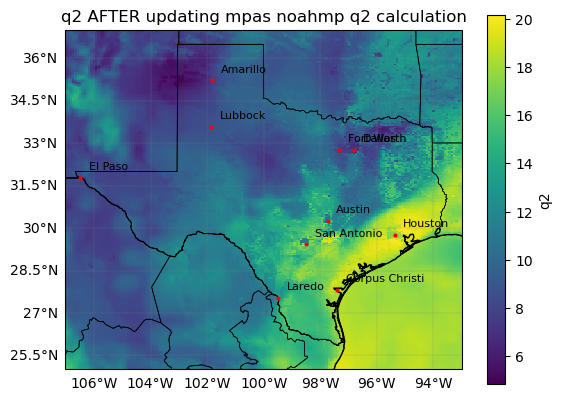

In [52]:
#AFTER FIX
import xarray as xr
filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/testing_q2/diag.2022-06-30_00.30.00.latlon.nc"
data = xr.open_dataset(filePath)
q2 = data['q2']

q2 = q2.sel(
    {latname: slice(25, 37), lonname: slice(-107, -93)}
)* 1000 

Plot(q2,title="q2 AFTER updating mpas noahmp q2 calculation")#,clim=clim)